# Telecom Customer Churn Prediction

---

## Project Overview

**What is customer churn?**  
Customer churn occurs when a customer cancels their telecom subscription.

**Why does it matter?**  
Acquiring a new customer costs 5–7× more than retaining one. Predicting which customers are likely to leave allows a company to intervene early with targeted offers or better support.

**Our goal**  
Explore the dataset, identify patterns in churner behaviour, and prepare the data for machine learning.

**Dataset**  
IBM Telco Customer Churn — 7,043 customers, 21 features covering demographics, services subscribed, and billing.  
Source: [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style='whitegrid')
print('Libraries loaded.')

---
## 1. Data Loading & Overview

We start by loading the raw dataset and understanding its structure — how many rows and columns, what data types each column has, and whether there are any obvious issues.

In [21]:
data = pd.read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {data.shape[0]} rows × {data.shape[1]} columns')
data.head()

Shape: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains **7,043 customer records** with **21 columns** covering:
- **Demographics**: gender, SeniorCitizen, Partner, Dependents
- **Services**: PhoneService, InternetService, StreamingTV, etc.
- **Account**: tenure, Contract, PaymentMethod, MonthlyCharges, TotalCharges
- **Target**: Churn (Yes / No)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observations from `.info()`:**

- `TotalCharges` is stored as `object` (string) — it should be a numeric column. This suggests some rows contain blank strings instead of numbers. We will fix this in preprocessing.
- `SeniorCitizen` is stored as `int64` (0/1) — it represents a Yes/No category. We will convert it to 'Yes'/'No' for clarity.
- All other columns look as expected.

In [23]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observations from `.describe()`:**

- `SeniorCitizen` mean ≈ 0.16, meaning only ~16% of customers are senior citizens.
- 75% of customers have a `tenure` of less than 55 months.
- Average `MonthlyCharges` is $64.76; the top 25% pay over $89.85/month.
- `TotalCharges` statistics are missing — confirming it was not recognised as numeric.

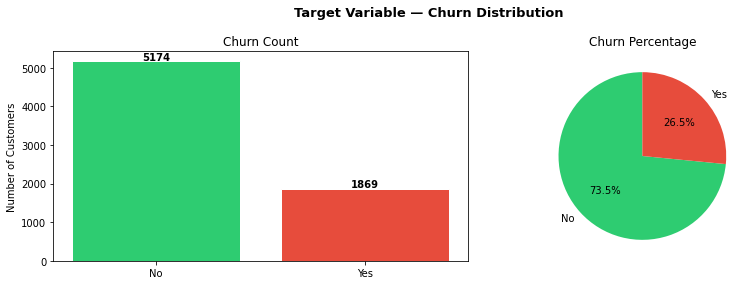

No     5174
Yes    1869
Name: Churn, dtype: int64

Churn rate: 26.5%


In [29]:
# Create one figure with 2 charts side by side
# 1, 2 means 1 row and 2 columns of charts
# figsize=(12, 4) sets the width=12 inches and height=4 inches
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left chart: Bar chart ──────────────────────────────────────────────────────

# Count how many customers said "Yes" (churned) and how many said "No" (stayed)
# value_counts() simply counts each unique value in the Churn column
counts = data['Churn'].value_counts()

# Draw a bar chart — green (#2ecc71) for No, red (#e74c3c) for Yes
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

# Write the exact number on top of each bar so it is easy to read
# enumerate() gives us both the position (i) and the value (v) for each bar
# v + 30 places the text just above the top of the bar
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# ── Right chart: Pie chart ─────────────────────────────────────────────────────

# normalize=True divides each count by the total number of rows
# Multiplying by 100 converts the decimal (e.g. 0.735) into a percentage (73.5%)
pct = data['Churn'].value_counts(normalize=True) * 100

# Draw the pie chart
# autopct='%1.1f%%' automatically adds the percentage label inside each slice (e.g. 73.5%)
# startangle=90 starts drawing the pie from the top (like a clock at 12)
axes[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage')

# ── Display ────────────────────────────────────────────────────────────────────

# suptitle adds one big title that sits above both charts
plt.suptitle('Target Variable — Churn Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()   # automatically adjusts spacing so charts don't overlap
plt.show()           # render and display the figure

# Also print the raw numbers as text below the chart
print(data['Churn'].value_counts())
print(f'\nChurn rate: {pct["Yes"]:.1f}%')  # e.g. "Churn rate: 26.5%"


- There are **5,174 non-churners (No)** and **1,869 churners (Yes)** — a ratio of approximately **73:27**.
- The dataset is **imbalanced**: the majority class (No Churn) is roughly 2.8× the minority class.
- This matters for model building — a naive model that always predicts 'No Churn' would achieve 73% accuracy without learning anything useful. We must account for this imbalance.

---
## 2. Data Cleaning & Preprocessing

Before we can visualise and model the data, we need to clean it and engineer features. We work on a copy of the original data so the raw dataset is preserved.

**Step 1 — Create a working copy of the data**

In [25]:
data1 = data.copy()

**Step 2 — Fix `TotalCharges`: convert from string to numeric**

`pd.to_numeric(..., errors='coerce')` converts valid numbers and turns blank strings into `NaN`.

In [26]:
data1['TotalCharges'] = pd.to_numeric(data1['TotalCharges'], errors='coerce')
print(f'NaN values in TotalCharges after conversion: {data1["TotalCharges"].isna().sum()}')

NaN values in TotalCharges after conversion: 11


**Step 3 — Inspect the 11 missing rows**

These are customers with `tenure = 0` — they just signed up and haven't been billed yet.

In [27]:
data1.loc[data1['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Step 4 — Drop the 11 null rows**

These 11 rows represent only 0.16% of the data — dropping them has negligible impact.

In [30]:
data1.dropna(inplace=True)
print(f'Rows after dropping nulls: {len(data1)}')

Rows after dropping nulls: 7032


**Step 5 — Convert `SeniorCitizen` from integer to categorical**

Replacing 0/1 with 'No'/'Yes' makes the column consistent with all other binary columns and produces clearer charts.

In [31]:
data1['SeniorCitizen'] = data1['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

**Step 6 — Engineer `tenure_group`: bin raw tenure into 12-month bands**

Instead of a raw number (0–72), we create 6 groups: 1–12, 13–24, 25–36, 36–48, 49–60, 61–72.  
This turns a continuous variable into an ordinal category, making patterns easier to spot in charts.
We then drop the original `tenure` column (and `customerID` which carries no predictive value).

In [32]:
labels = ['{0} - {1}'.format(i, i + 11) for i in range(1, 72, 12)]
data1['tenure_group'] = pd.cut(data1.tenure, bins=range(1, 80, 12),
                                right=False, labels=labels).astype('object')

data1.drop(columns=['tenure', 'customerID'], inplace=True)

print('Customers per tenure group:')
print(data1['tenure_group'].value_counts().sort_index())

Customers per tenure group:
1 - 12     2175
13 - 24    1024
25 - 36     832
37 - 48     762
49 - 60     832
61 - 72    1407
Name: tenure_group, dtype: int64


**Step 7 — Simplify redundant categories**

Several columns have a third value like `'No phone service'` or `'No internet service'`.  
These are redundant — if a customer has no phone service, they cannot have multiple lines either.  
Collapsing these to `'No'` simplifies encoding.

In [33]:
# Confirm the redundant values exist
print('MultipleLines values before:', data1['MultipleLines'].unique())

data1.replace({'No phone service': 'No', 'No internet service': 'No'}, inplace=True)

print('MultipleLines values after: ', data1['MultipleLines'].unique())

MultipleLines values before: ['No phone service' 'No' 'Yes']
MultipleLines values after:  ['No' 'Yes']


**Step 8 — Save the cleaned dataset, then encode for visualisation**

We save `tel_churn.csv` now — *before* one-hot encoding — so that `2_Model_Building.ipynb` can load a clean, human-readable file and apply its own encoding.  
We then encode here purely to produce the visualisations below.

In [34]:
# Save cleaned data BEFORE encoding — keeps tel_churn.csv human-readable for the model notebook
data1.to_csv('tel_churn.csv', index=False)
print('tel_churn.csv saved.')

# Convert Yes/No to 1/0 so maths can be done on the Churn column
data1['Churn'] = data1['Churn'].map({'No': 0, 'Yes': 1})

# Convert ALL remaining text columns into 0/1 columns (one column per category value)
# e.g. Contract → Contract_Month-to-month, Contract_One year, Contract_Two year
# Goes from ~20 columns to 45 — needed for correlation charts below
data_dummies = pd.get_dummies(data1)
print(f'Encoded dataset shape: {data_dummies.shape}')
data_dummies.head(3)


tel_churn.csv saved.
Encoded dataset shape: (7032, 45)


,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,29.85,29.85,0,1,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,0
1,56.95,1889.50,0,0,1,1,0,1,0,1,...,0,0,0,1,0,0,1,0,0,0
2,53.85,108.15,1,0,1,1,0,1,0,1,...,0,0,0,1,1,0,0,0,0,0


---
## 3. Data Visualization & Analysis

1. Plot distribution of individual predictors by churn

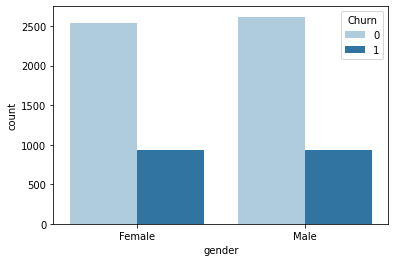

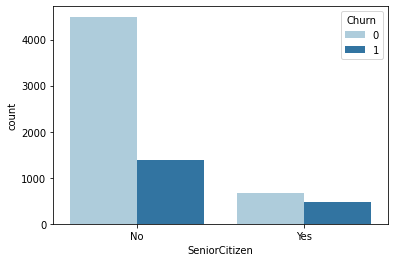

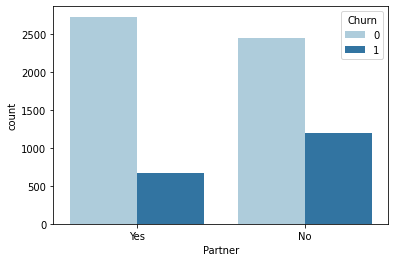

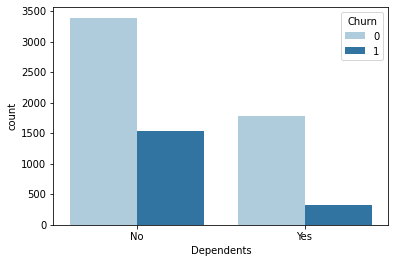

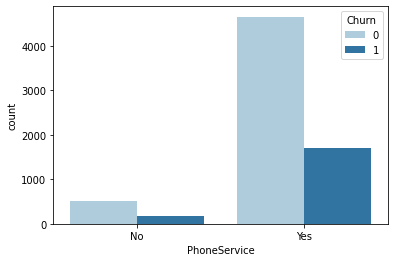

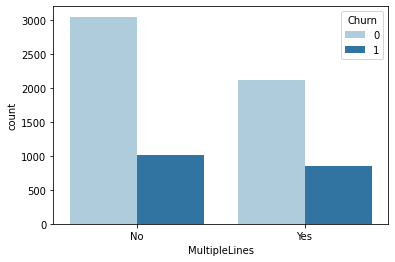

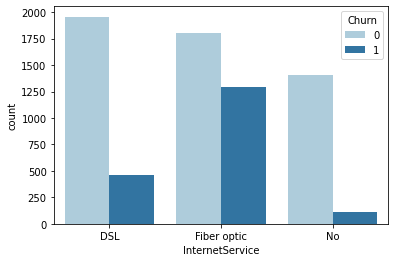

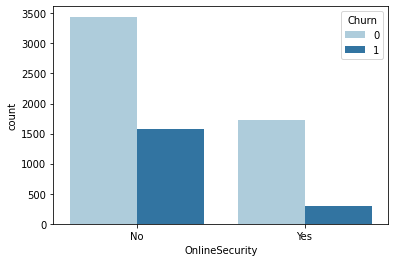

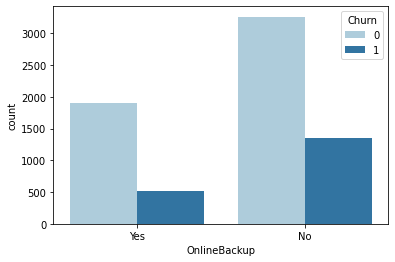

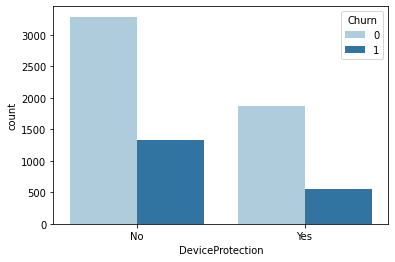

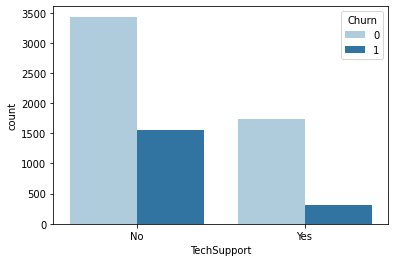

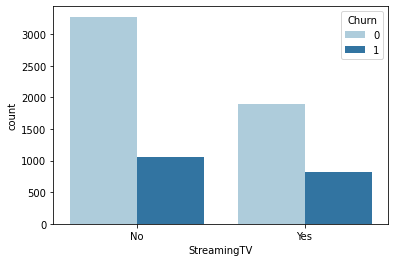

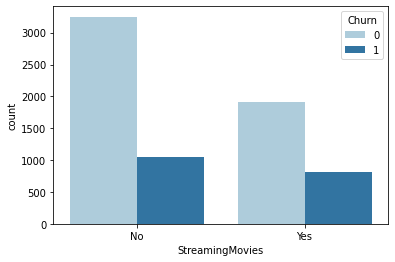

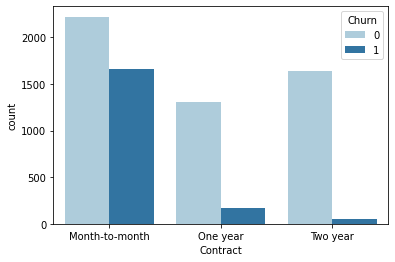

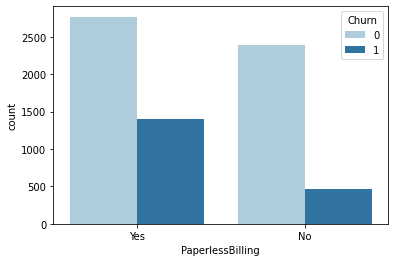

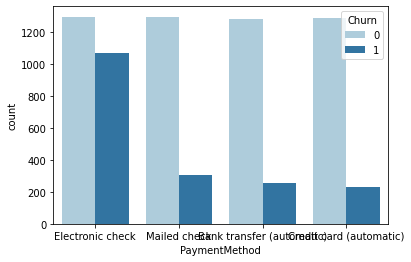

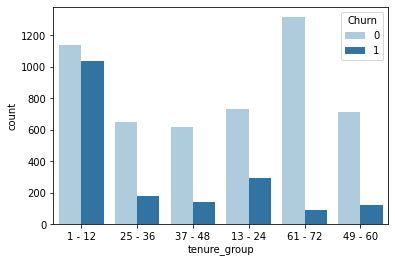

In [31]:
for i, predictor in enumerate(data1.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])): #excluding numerical columns and target variable
    plt.figure(i)
    palette = sns.color_palette("Paired")
    sns.countplot(data=data1, x=predictor, hue='Churn', palette=palette)

2. Relationship between MonthlyCharges and TotalCharges

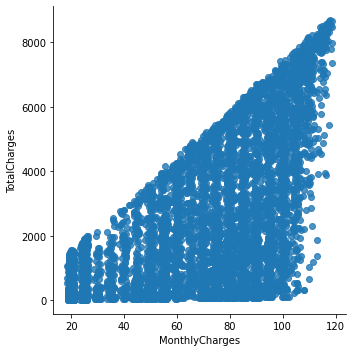

In [32]:
sns.lmplot(data=data_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False);

- As expected, TotalCharges increases with increase in MonthlyCharges.

3. Churn by MonthlyCharges and TotalCharges

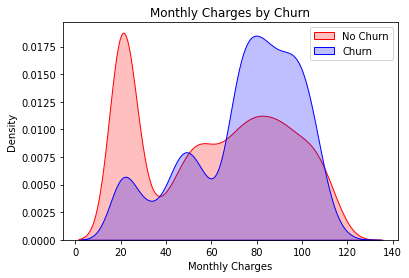

In [ ]:
#kernel density estimate It estimates the probability density of continuous data.
mth = sns.kdeplot(data_dummies.MonthlyCharges[(data_dummies["Churn"] == 0)], color='Red', fill=True)
mth = sns.kdeplot(data_dummies.MonthlyCharges[(data_dummies["Churn"] == 1)], ax=mth, color='Blue', fill=True)

mth.set_title("Monthly Charges by Churn")
mth.set_xlabel("Monthly Charges")
mth.set_ylabel("Density")
mth.legend(["No Churn", "Churn"], loc='upper right');

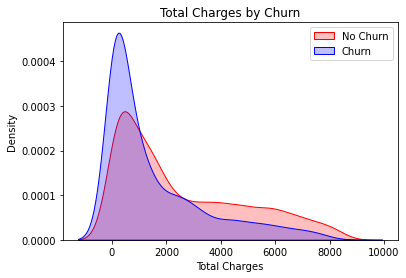

In [34]:
ttl = sns.kdeplot(data_dummies.TotalCharges[(data_dummies['Churn'] == 0)], color='Red', fill=True)
ttl = sns.kdeplot(data_dummies.TotalCharges[(data_dummies['Churn'] == 1)], ax=ttl, color='Blue', fill=True)

ttl.set_title("Total Charges by Churn")
ttl.set_xlabel("Total Charges")
ttl.set_ylabel("Density")
ttl.legend(["No Churn", "Churn"], loc='upper right');

- **Surprising insight:** Higher churn is seen at *lower* TotalCharges.
- However, combining with other attributes makes this clear: customers with **higher MonthlyCharges** but **low tenure** will naturally have low TotalCharges.
- All three factors are linked: **Higher Monthly Charges + Lower Tenure = Lower Total Charges = Higher Churn Risk**.

4. Build a correlation of all predictors with Churn

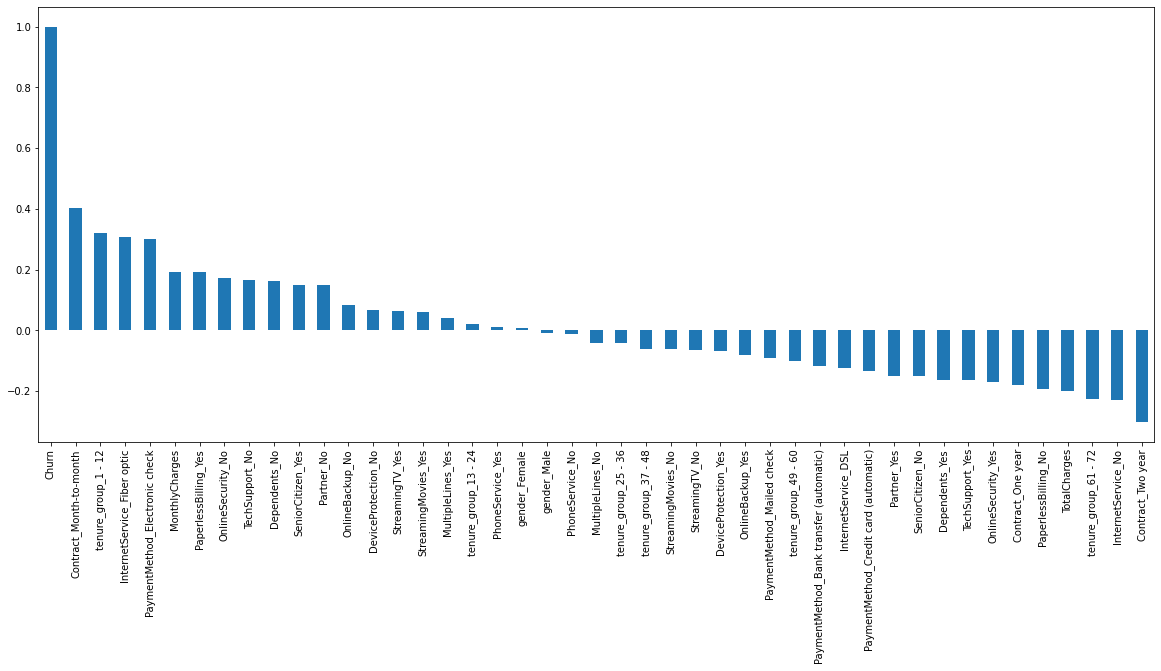

In [35]:
plt.figure(figsize=(20, 8))
data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar');

- High Churn seen in case of __Month to month contracts__, __No online security__, __No tech support__, __First year of subscription(tenure)__ & __Fibre optics internet__<br>
- Low Churn is seen in case of __Long term contracts__, __Subscriptions without internet service__ and __Customers who are engaged for 5+ years__<br>
- Factors like __Gender__, __Availability of phone service__ and __Customers with multiple lines__ have almost no impact on Churn<br>
This is also evident from the heatmap below

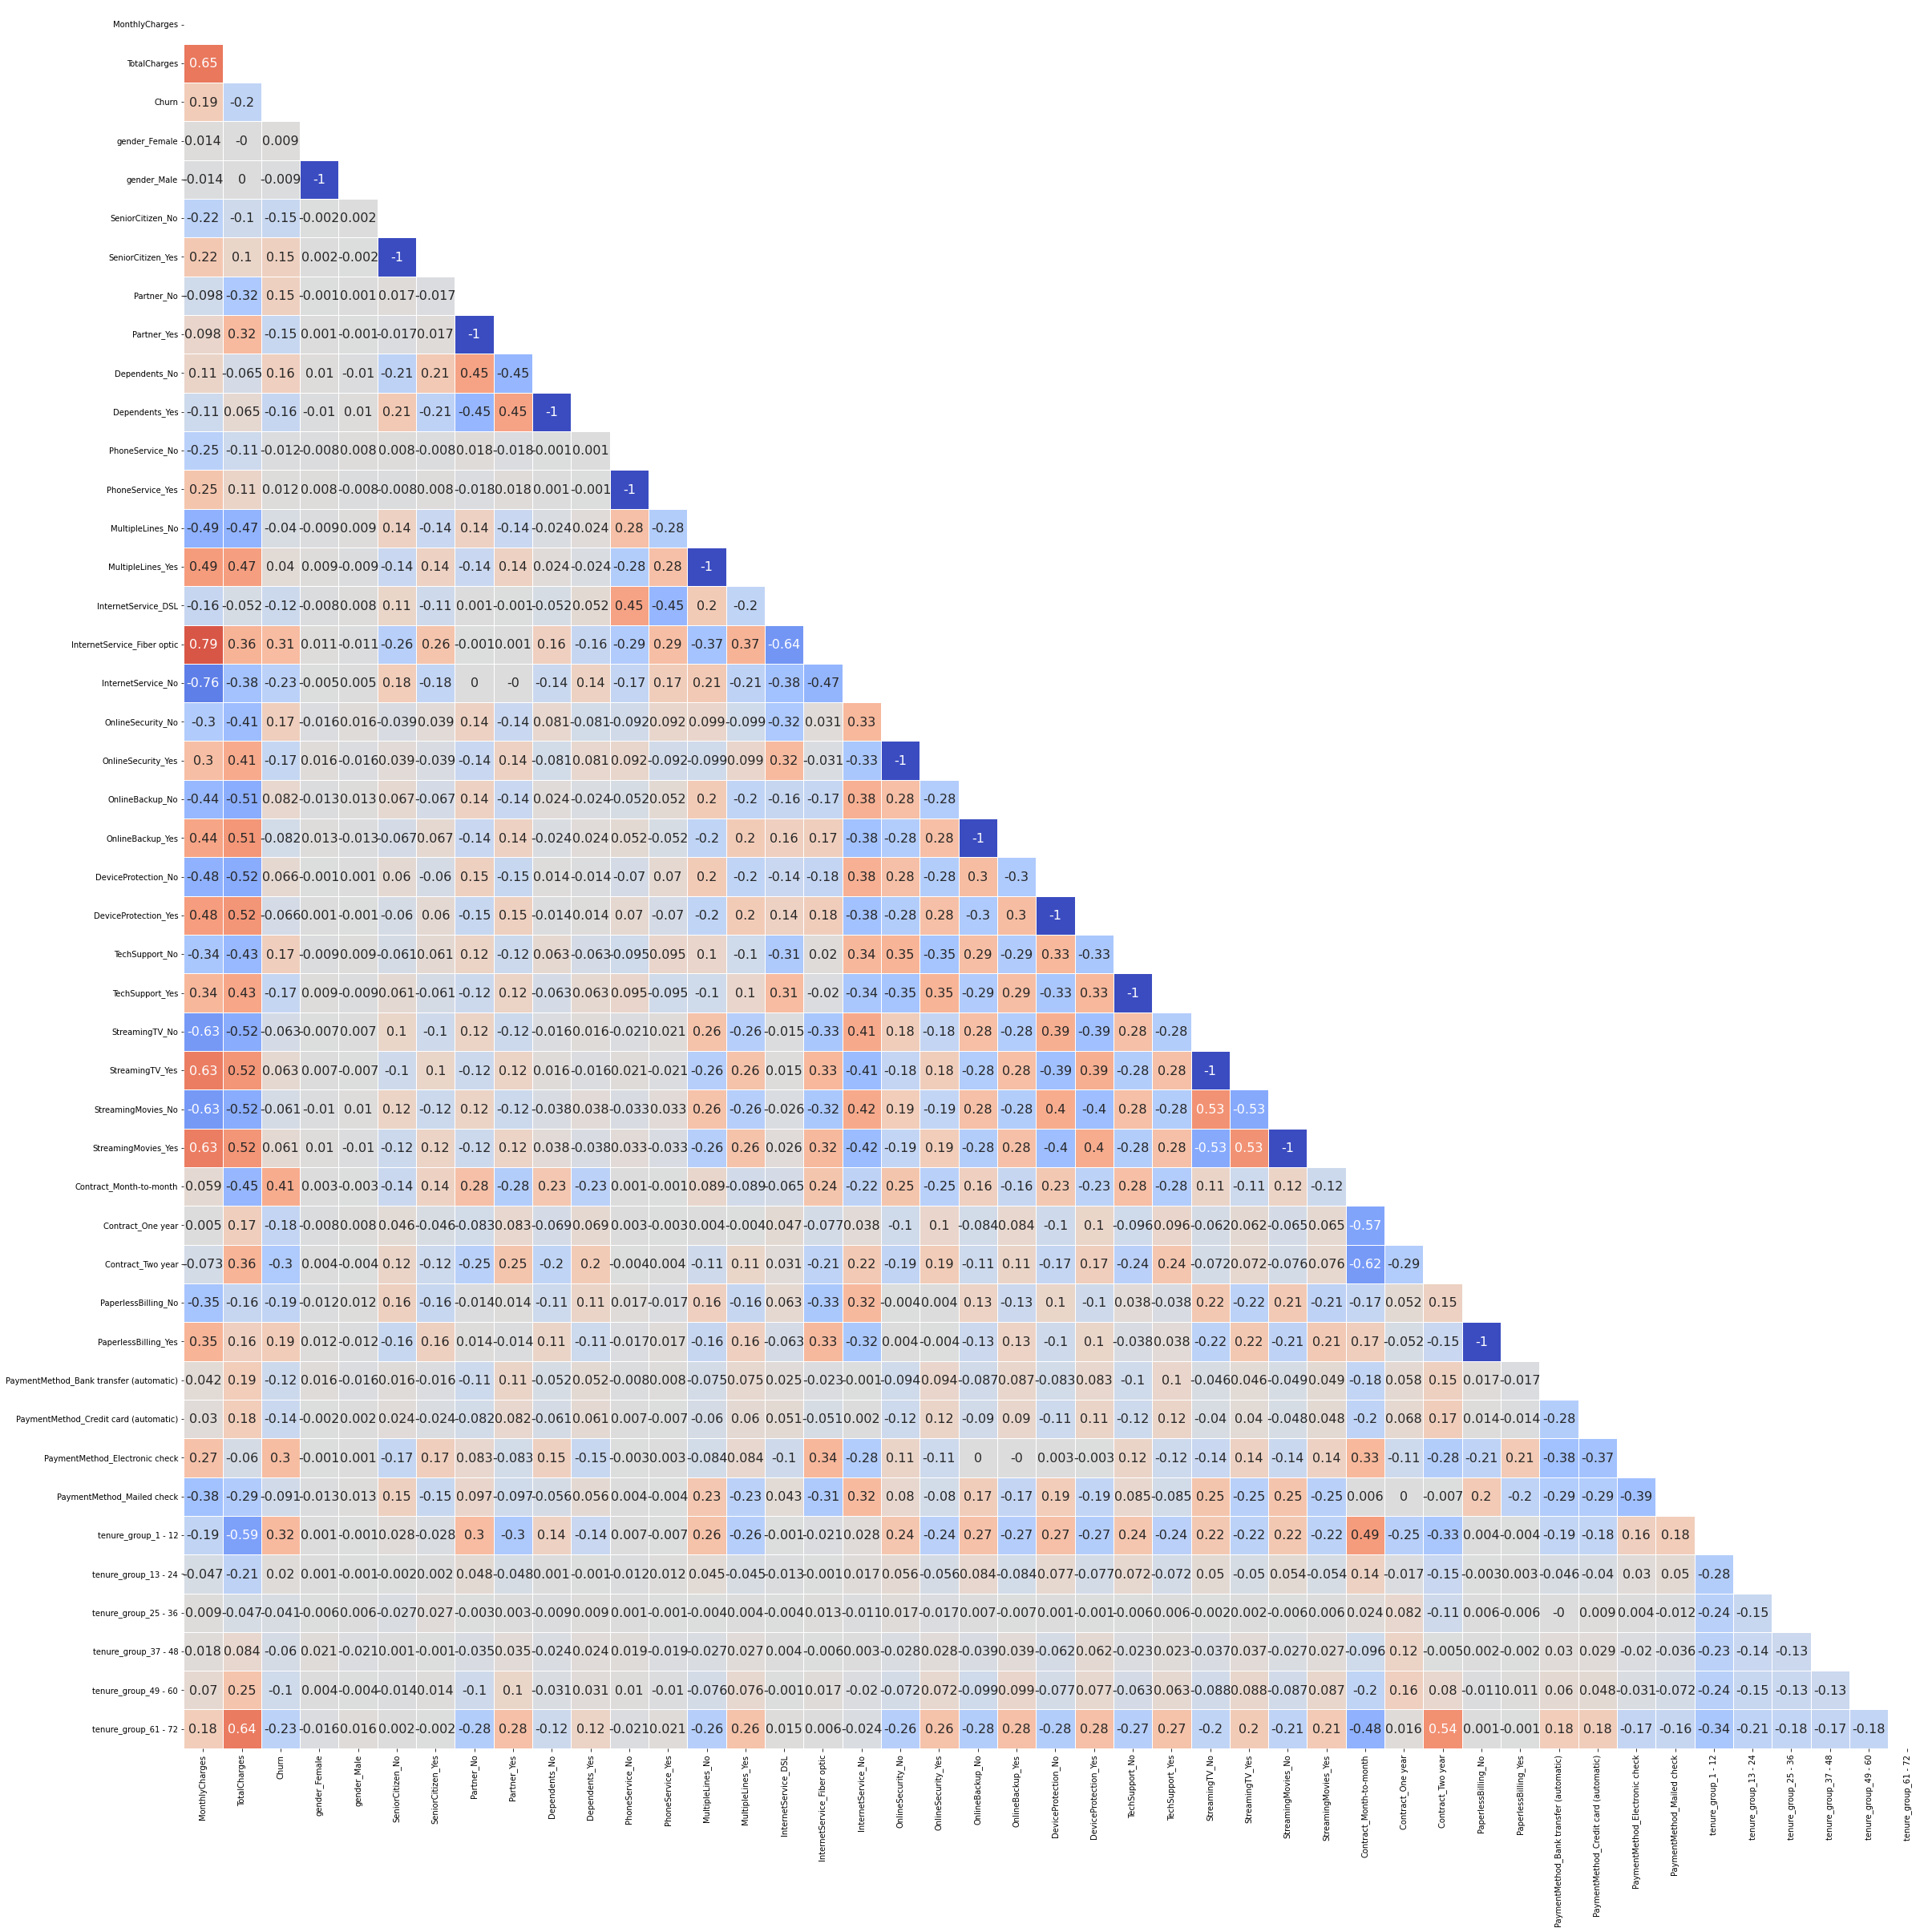

In [37]:
corr_matrix = data_dummies.corr().round(3)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cbar=False,
            cmap='coolwarm', linewidth=1, mask=mask,
            square=True, annot=True, fmt='.2f', annot_kws={'fontsize':8}, ax=ax)

plt.show()

5. Distribution of Different Attributes by Gender

In [35]:
data2_target0 = data1.loc[data1['Churn']==0]
data2_target1 = data1.loc[data1['Churn']==1]

In [39]:
def uniplot(df, col, title, hue=None):

    # Set background to white grid and font sizes to "talk" (larger, presentation-friendly)
    sns.set_style('whitegrid')
    sns.set_context('talk')

    # Set axis label and title font sizes manually
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30   # gap between title and chart

    # Convert the hue column (e.g. gender) into a Series to count its unique values
    temp = pd.Series(data=hue)

    # Create a blank figure and axis
    fig, ax = plt.subplots()

    # Auto-size the chart width based on how many bars there will be
    # More unique values in col or hue → wider chart so bars don't squish together
    width = len(df[col].unique()) + 7 + 4 * len(temp.unique())
    fig.set_size_inches(width, 8)

    # Rotate x-axis labels 45° so they don't overlap each other
    plt.xticks(rotation=45)

    # Set the chart title
    plt.title(title)

    # Draw the bar chart — bars are ordered by most frequent first
    # hue splits each bar by gender (or whatever hue column is passed in)
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index,
                       hue=hue, palette='bright')

    plt.show()


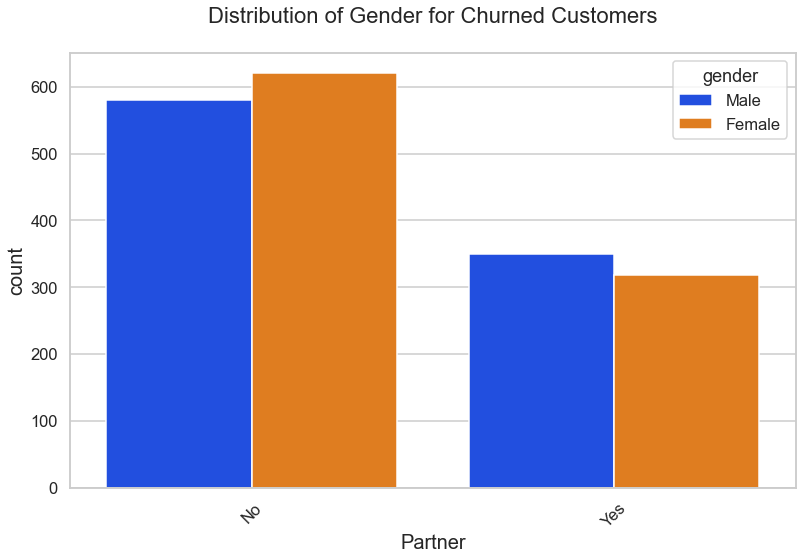

In [40]:
uniplot(df=data2_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')

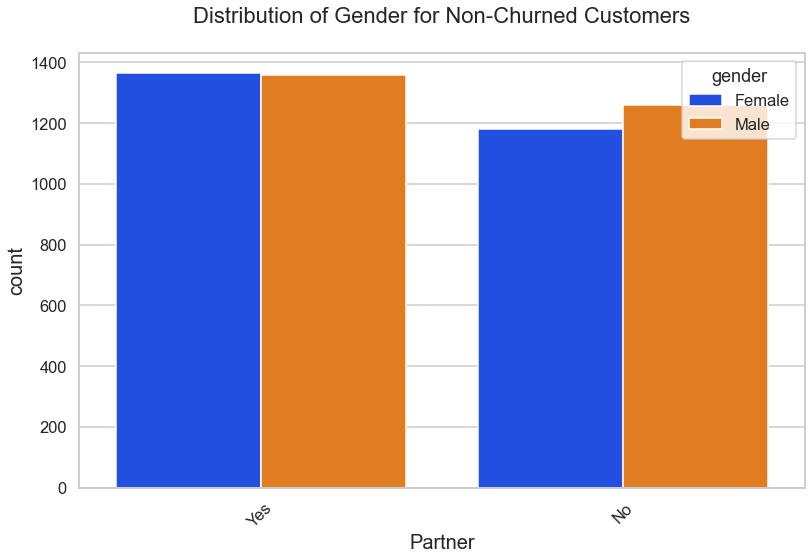

In [41]:
uniplot(df=data2_target0, col='Partner', title='Distribution of Gender for Non-Churned Customers', hue='gender')

- Female Customers with no Partner tend to Churn a little more than Male Customers
- Male and Female Customers with Partner are the most Non-Churners

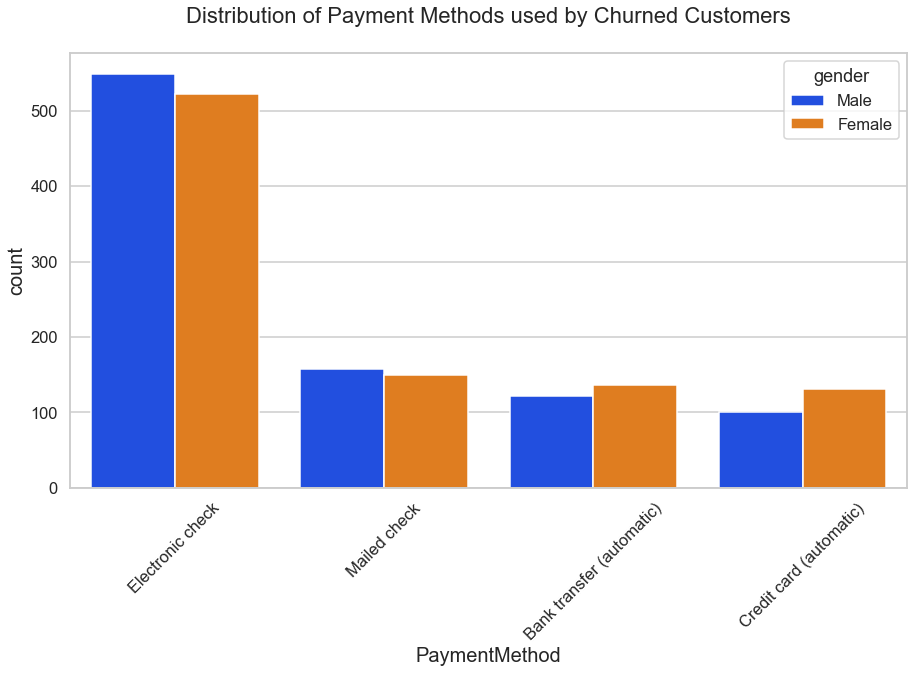

In [42]:
uniplot(df=data2_target1, col='PaymentMethod', title='Distribution of Payment Methods used by Churned Customers', hue='gender')

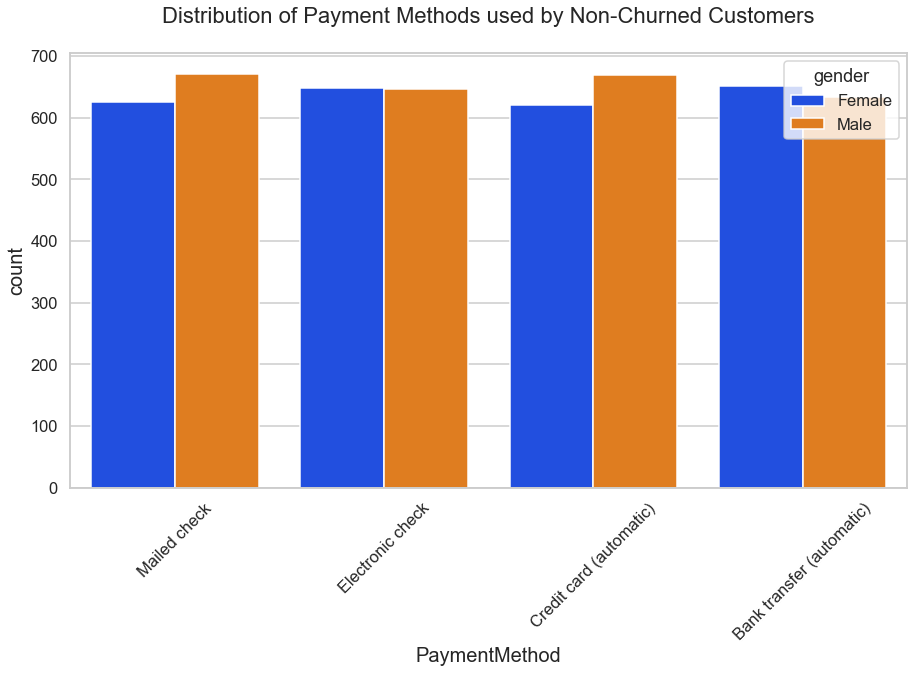

In [43]:
uniplot(df=data2_target0, col='PaymentMethod', title='Distribution of Payment Methods used by Non-Churned Customers', hue='gender')

- The most popular payment method used by Churners is 'Electronic check'
- Male Customers with payment methods of 'Mailed check' and 'Credit card (automatic)' are the least Churners

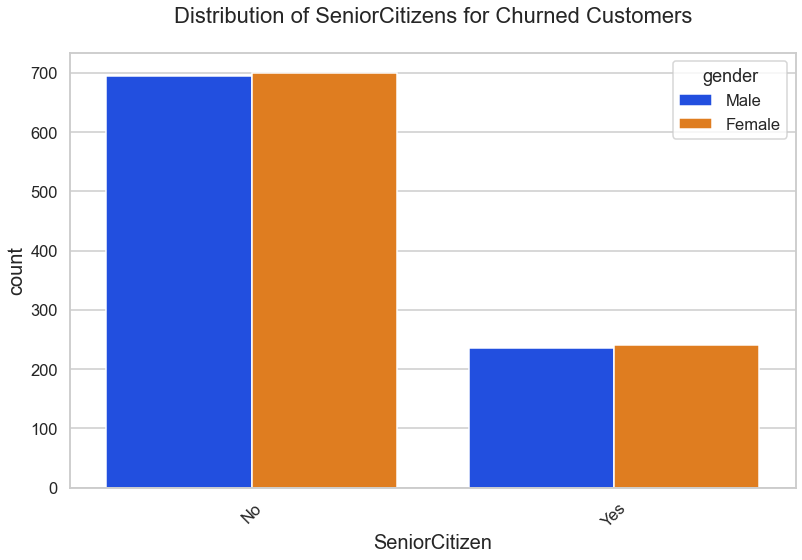

In [44]:
uniplot(data2_target1, col='SeniorCitizen', title='Distribution of SeniorCitizens for Churned Customers', hue='gender')

- Non-Senior Citizens Churn significantly more than the Senior Citizens with respect to both genders

---
## 4. EDA Conclusion

### Key Insights from EDA

| Factor | Finding |
|--------|--------|
| **Contract type** | Month-to-month customers churn most (~43%) vs two-year contracts (~3%) |
| **Tenure** | Most churners leave within the first 12 months |
| **Internet service** | Fibre optic users churn at ~42% vs ~19% for DSL |
| **Payment method** | Electronic check users have the highest churn rate |
| **Add-on services** | No online security / tech support → higher churn |
| **Gender** | Almost no impact on churn |
| **Senior citizens** | Non-senior citizens churn more than senior citizens |

These findings directly guide which features will be most important to our machine learning models in `2_Model_Building.ipynb`.

---
> **Next step:** Open `2_Model_Building.ipynb` to train and compare the three models.  
> Make sure this notebook has run fully first — it saves `tel_churn.csv` which the model notebook loads.